In [1]:
from QLBM import QLBM, collision, InitializeQC
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 16, 32
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 60000
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [ ]:
Q = 9
Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
Re = 10
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
f_star = np.zeros((Nx+1, Ny+1, Q))
fq = np.zeros((Nx+1, Ny+1, Q))

rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])

u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
u_t = np.zeros((Nx+3, Ny+3))
v_t = np.zeros((Nx+3, Ny+3))
uq_t = np.zeros((Nx+3, Ny+3))
vq_t = np.zeros((Nx+3, Ny+3))

dx = dt = 1
c = dx/dt
Lx = (Nx+1)/2
Ly = (Ny+1)/2

U = 0.08
nu = U*Lx/(Re)
x0 = np.linspace(-Lx+dx/4,Lx-dx/4,Ny+1)

y0 = np.linspace(-Lx+dx/2,Lx-dx/2,Nx+1)
X,Y = np.meshgrid(x0,y0)

dx = dt = 0.8*np.min([np.min(X[:,1:]-X[:,:-1]),np.min(Y[1:,:]-Y[:-1,:])])
X_t = np.zeros((Nx+3,Ny+3))
Y_t = np.zeros((Nx+3,Ny+3))
X_t[1:-1,1:-1] = X.copy()
X_t[0,:] = X_t[2,:]
X_t[-1,:] = X_t[-3,:]
X_t[:,0] = 2.0*X_t[:,1] - X_t[:,2]
X_t[:,-1] = 2.0*X_t[:,-2] - X_t[:,-3]

Y_t[1:-1,1:-1] = Y.copy()
Y_t[0,:] = 2.0*Y_t[1,:] - Y_t[2,:]
Y_t[-1,:] = 2.0*Y_t[-2,:] - Y_t[-3,:]
Y_t[:,0] = Y_t[:,1]
Y_t[:,-1] = Y_t[:,-2]


delta_x = (X[:,1:]-X[:,:-1])#[:-1,:]
delta_y = (Y[1:,:]-Y[:-1,:])#[:,:-1]
deltat_x = (X_t[:,1:]-X_t[:,:-1])[1:-1,:]#[:-1,:]
deltat_y = (Y_t[1:,:]-Y_t[:-1,:])[:,1:-1]#[:,:-1]

y_0 = np.zeros((Nx+1,Ny+1,Q))
x_0 = np.zeros((Nx+1,Ny+1,Q))
for i in range(Q):
    x_0[:,:,i] = X + e[i,0]*dt
    y_0[:,:,i] = Y + e[i,1]*dt

nu_star = 1/6*dt
cs = np.sqrt(c**2/3)
tau_f = 1.0
t_s = 1.0
TIMESTEPS = int(t_s*Lx/U/dt)

print(nu-nu_star,tau_f,cs**2,TIMESTEPS)
q_error = []
c_error = []
qc_error = []

[-7.75 -7.25 -6.75 -6.25 -5.75 -5.25 -4.75 -4.25 -3.75 -3.25 -2.75 -2.25
 -1.75 -1.25 -0.75 -0.25  0.25  0.75  1.25  1.75  2.25  2.75  3.25  3.75
  4.25  4.75  5.25  5.75  6.25  6.75  7.25  7.75]
(16, 32)
(18, 34)
7.75 -7.75 1.0 1.0
7.5 -7.5 0.5 0.5
(16, 31) (15, 32)
[[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
  0.5 0.5 0.5

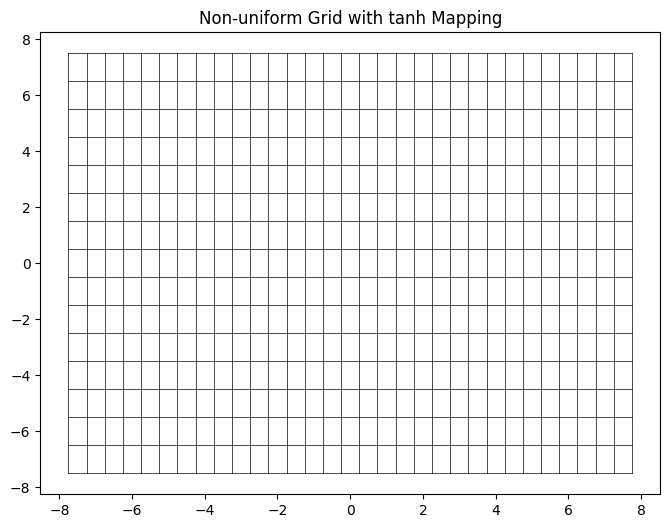

In [ ]:
# Mesh
plt.figure(figsize=(8, 6))
plt.plot(X, Y, 'k', lw=0.5)
plt.plot(X.T, Y.T, 'k', lw=0.5)
#plt.plot(x_0[:,:,2], y_0[:,:,2], 'r', lw=0.5)
#plt.plot(x_0[:,:,2].T, y_0[:,:,2].T, 'r', lw=0.5)
plt.title('Non-uniform Grid with tanh Mapping')
plt.show()

In [ ]:
neighbors = [list() for i in range(Nx-1)]
for ff in range(len(neighbors)):
    neighbors[ff].extend([list() for e in range(Ny-1)])
for i in range(1, Nx):
    for j in range(1, Ny):
        neighbors[i-1][j-1] = [
            (i,     j), (i-1, j), (i-1, j+1),
            (i-1, j-1), (i, j-1), (i,   j+1),
            (i+1, j-1), (i+1, j), (i+1, j+1)
        ]

In [ ]:
## 3D
def Matrix(X_star,Y_star, N_fx, N_fy,X_star1,Y_star1, n,neighbors):
    m = 6
    M1 = np.zeros((n,m))
    M2 = np.zeros((N_fx-2,N_fy-2,m,n))

    for i in range(1,N_fx-1):
        for j in range(1,N_fy-1):
            k = 0
            W = np.zeros((n,n))
            for (ni, nj) in neighbors[i-1][j-1]:
                
                M1[k, 0] = 1.0
                M1[k, 1] = (-X_star[i, j] + X_star1[ni, nj])
                M1[k, 2] = (-Y_star[i, j] + Y_star1[ni, nj])
                M1[k, 3] = 0.5*(-X_star[i, j] + X_star1[ni, nj])**2
                M1[k, 4] = 0.5*(-Y_star[i, j] + Y_star1[ni, nj])**2
                M1[k, 5] = (-X_star[i, j] + X_star1[ni, nj])*(-Y_star[i, j] + Y_star1[ni, nj])
                k = k+1

            M2[i-1,j-1,:,:] = np.dot(np.linalg.inv(np.dot((M1.T), M1)), M1.T)
        
    return M2[:,:,0,:]

In [ ]:
def Matrix_quadratic(X_star,Y_star, N_fx, N_fy,X_star1,Y_star1, n,neighbors,QQ):
    m = 6
    M = np.zeros((N_fx-2,N_fy-2,m,n))

    for i in range(1,N_fx-1):
        for j in range(1,N_fy-1):
            x0 = X_star1[neighbors[i-1][j-1][4][0], neighbors[i-1][j-1][4][1]]
            x1 = X_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
            x2 = X_star1[neighbors[i-1][j-1][2][0], neighbors[i-1][j-1][2][1]]
            y0 = Y_star1[neighbors[i-1][j-1][1][0], neighbors[i-1][j-1][1][1]]
            y1 = Y_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
            y2 = Y_star1[neighbors[i-1][j-1][6][0], neighbors[i-1][j-1][6][1]]
            xm = X_star[i, j]
            ym = Y_star[i, j]
            M0 = (xm-x1)*(xm-x2)/((x0-x1)*(x0-x2))
            D0 = (ym-y1)*(ym-y2)/((y0-y1)*(y0-y2))
            M1 = (xm-x0)*(xm-x2)/((x1-x0)*(x1-x2))
            D1 = (ym-y0)*(ym-y2)/((y1-y0)*(y1-y2))
            M2 = (xm-x0)*(xm-x1)/((x2-x0)*(x2-x1))
            D2 = (ym-y0)*(ym-y1)/((y2-y0)*(y2-y1))
            if i==5 and j==5:
                print(x0,x1,x2,y0,y1,y2,xm,ym,M1.shape,type(M1))
            
            M[i-1,j-1,0,0] = M1*D1
            M[i-1,j-1,0,1] = M1*D0
            M[i-1,j-1,0,2] = M2*D0
            M[i-1,j-1,0,3] = M0*D0
            M[i-1,j-1,0,4] = M0*D1
            M[i-1,j-1,0,5] = M2*D1
            M[i-1,j-1,0,6] = M0*D2
            M[i-1,j-1,0,7] = M1*D2
            M[i-1,j-1,0,8] = M2*D2
            
        
    return M[:,:,0,:]

In [ ]:
def Matrix_linear(X_star,Y_star, N_fx, N_fy,X_star1,Y_star1, n,neighbors,QQ):
    m = 6
    M = np.zeros((N_fx-2,N_fy-2,m,n))

    for i in range(1,N_fx-1):
        for j in range(1,N_fy-1):
            x0 = X_star1[neighbors[i-1][j-1][4][0], neighbors[i-1][j-1][4][1]]
            x1 = X_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
            x2 = X_star1[neighbors[i-1][j-1][2][0], neighbors[i-1][j-1][2][1]]
            y0 = Y_star1[neighbors[i-1][j-1][1][0], neighbors[i-1][j-1][1][1]]
            y1 = Y_star1[neighbors[i-1][j-1][0][0], neighbors[i-1][j-1][0][1]]
            y2 = Y_star1[neighbors[i-1][j-1][6][0], neighbors[i-1][j-1][6][1]]
            xm = X_star[i, j]
            ym = Y_star[i, j]
            if QQ==1:
                M[i-1,j-1,0,0] = (xm-x0)/(x1-x0)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = (x1-xm)/(x1-x0)
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==2:
                M[i-1,j-1,0,0] = (ym-y0)/(y1-y0)
                M[i-1,j-1,0,1] = (y1-ym)/(y1-y0)
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==3:
                M[i-1,j-1,0,0] = (x2-xm)/(x2-x1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = (xm-x1)/(x2-x1)
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==4:
                M[i-1,j-1,0,0] = (y2-ym)/(y2-y1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = (ym-y1)/(y2-y1)
                M[i-1,j-1,0,8] = 0
            elif QQ==5:
                M[i-1,j-1,0,0] = (xm-x0)*(ym-y0)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,1] = (xm-x0)*(y1-ym)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = (x1-xm)*(y1-ym)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,4] = (x1-xm)*(ym-y0)/(x1-x0)/(y1-y0)
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==6:
                M[i-1,j-1,0,0] = (x2-xm)*(ym-y0)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,1] = (x2-xm)*(y1-ym)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,2] = (xm-x1)*(y1-ym)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = (xm-x1)*(ym-y0)/(x2-x1)/(y1-y0)
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = 0
                M[i-1,j-1,0,8] = 0
            elif QQ==7:
                M[i-1,j-1,0,0] = (x2-xm)*(y2-ym)/(x2-x1)/(y2-y1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = 0
                M[i-1,j-1,0,5] = (xm-x1)*(y2-ym)/(x2-x1)/(y2-y1)
                M[i-1,j-1,0,6] = 0
                M[i-1,j-1,0,7] = (x2-xm)*(ym-y1)/(x2-x1)/(y2-y1)
                M[i-1,j-1,0,8] = (xm-x1)*(ym-y1)/(x2-x1)/(y2-y1)
            elif QQ==8:
                M[i-1,j-1,0,0] = (xm-x0)*(y2-ym)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,1] = 0
                M[i-1,j-1,0,2] = 0
                M[i-1,j-1,0,3] = 0
                M[i-1,j-1,0,4] = (x1-xm)*(y2-ym)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,5] = 0
                M[i-1,j-1,0,6] = (x1-xm)*(ym-y1)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,7] = (xm-x0)*(ym-y1)/(x1-x0)/(y2-y1)
                M[i-1,j-1,0,8] = 0
        
    return M[:,:,0,:]

In [ ]:
MM = np.zeros((Nx-1,Ny-1,Q-1,9))
for ii in range(1,Q):
    MM[:,:,ii-1,:] = Matrix_linear(X,Y, X.shape[0], X.shape[1],x_0[:,:,ii],y_0[:,:,ii],9,neighbors,ii)#_quadratic

In [11]:
def matrix_SVD(M):
    Nxx, Nyy, _  = M.shape
    Nyy +=2
    Nxx +=2
    M_SVD = np.zeros((Nxx*Nyy,Nxx*Nyy))
    for i in range(Nyy):
        for j in range(Nxx):
            MMS = np.zeros((Nxx,Nyy))
            if i == 0 and j == 0:
                MMS[0,0] = M[0,0,0]
                MMS[-1,0] = M[0,0,1]
                MMS[-1,1] = M[0,0,2]
                MMS[-1,-1] = M[0,0,3]
                MMS[0,-1] = M[0,0,4]
                MMS[0,1] = M[0,0,5]
                MMS[1,-1] = M[0,0,6]
                MMS[1,0] = M[0,0,7]
                MMS[1,1] = M[0,0,8]
            elif i == 0 and j == Nxx-1:
                MMS[-1,0] = M[0,0,0]
                MMS[-2,0] = M[0,0,1]
                MMS[-2,1] = M[0,0,2]
                MMS[-2,-1] = M[0,0,3]
                MMS[-1,-1] = M[0,0,4]
                MMS[-1,1] = M[0,0,5]
                MMS[0,-1] = M[0,0,6]
                MMS[0,0] = M[0,0,7]
                MMS[0,1] = M[0,0,8]
            elif i == Nyy-1 and j == 0:
                MMS[0,-1] = M[0,0,0]
                MMS[-1,-1] = M[0,0,1]
                MMS[-1,0] = M[0,0,2]
                MMS[-1,-2] = M[0,0,3]
                MMS[0,-2] = M[0,0,4]
                MMS[0,0] = M[0,0,5]
                MMS[1,-2] = M[0,0,6]
                MMS[1,-1] = M[0,0,7]
                MMS[1,0] = M[0,0,8]
            elif i == Nyy-1 and j == Nxx-1:
                MMS[-1,-1] = M[0,0,0]
                MMS[-2,-1] = M[0,0,1]
                MMS[-2,0] = M[0,0,2]
                MMS[-2,-2] = M[0,0,3]
                MMS[-1,-2] = M[0,0,4]
                MMS[-1,0] = M[0,0,5]
                MMS[0,-2] = M[0,0,6]
                MMS[0,-1] = M[0,0,7]
                MMS[0,0] = M[0,0,8]
            elif i == 0 and 0 < j < Nxx-1:
                MMS[j,0] = M[0,0,0]
                MMS[j-1,0] = M[0,0,1]
                MMS[j-1,1] = M[0,0,2]
                MMS[j-1,-1] = M[0,0,3]
                MMS[j,-1] = M[0,0,4]
                MMS[j,1] = M[0,0,5]
                MMS[j+1,-1] = M[0,0,6]
                MMS[j+1,0] = M[0,0,7]
                MMS[j+1,1] = M[0,0,8]
            elif i == Nyy-1 and 0 < j < Nxx-1:
                MMS[j,-1] = M[0,0,0]
                MMS[j-1,-1] = M[0,0,1]
                MMS[j-1,0] = M[0,0,2]
                MMS[j-1,-2] = M[0,0,3]
                MMS[j,-2] = M[0,0,4]
                MMS[j,0] = M[0,0,5]
                MMS[j+1,-2] = M[0,0,6]
                MMS[j+1,-1] = M[0,0,7]
                MMS[j+1,0] = M[0,0,8]
            elif 0 < i < Nyy-1 and j == 0:
                MMS[0,i] = M[0,0,0]
                MMS[-1,i] = M[0,0,1]
                MMS[-1,i+1] = M[0,0,2]
                MMS[-1,i-1] = M[0,0,3]
                MMS[0,i-1] = M[0,0,4]
                MMS[0,i+1] = M[0,0,5]
                MMS[1,i-1] = M[0,0,6]
                MMS[1,i] = M[0,0,7]
                MMS[1,i+1] = M[0,0,8]
            elif 0 < i < Nyy-1 and j == Nxx-1:
                MMS[-1,i] = M[0,0,0]
                MMS[-2,i] = M[0,0,1]
                MMS[-2,i+1] = M[0,0,2]
                MMS[-2,i-1] = M[0,0,3]
                MMS[-1,i-1] = M[0,0,4]
                MMS[-1,i+1] = M[0,0,5]
                MMS[0,i-1] = M[0,0,6]
                MMS[0,i] = M[0,0,7]
                MMS[0,i+1] = M[0,0,8]
            else:
                MMS[j,i] = M[j-1,i-1,0]
                MMS[(j-1),i] = M[j-1,i-1,1]
                MMS[(j-1),i+1] = M[j-1,i-1,2]
                MMS[(j-1),i-1] = M[j-1,i-1,3]
                MMS[(j),i-1] = M[j-1,i-1,4]
                MMS[(j),i+1] = M[j-1,i-1,5]
                MMS[(j+1),i-1] = M[j-1,i-1,6]
                MMS[(j+1),i] = M[j-1,i-1,7]
                MMS[(j+1),i+1] = M[j-1,i-1,8]
            M_SVD[i*(Nxx)+j,:] = MMS.flatten(order='F')
    return M_SVD

In [ ]:
M_s = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
M_SVD1 = np.zeros(((Nx+1)*(Ny+1),(Nx+1)*(Ny+1)))
for i in range(Ny+1):
    for j in range(Nx+1):
        MMS = np.zeros((Nx+1,Ny+1))
        MMS[j,i] = 1.0
        M_SVD1[i*(Nx+1)+j,:] = MMS.flatten(order='F')
M_s[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = M_SVD1

for i in range(1,Q):
    M_s[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = matrix_SVD(MM[:,:,i-1,:])

In [13]:
UU_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
S_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
VV_SVD = np.zeros(((Nx+1)*(Ny+1)*Q,(Nx+1)*(Ny+1)*Q))
M_SVD1 = np.zeros(((Nx+1)*(Ny+1),(Nx+1)*(Ny+1)))
for i in range(Ny+1):
    for j in range(Nx+1):
        MMS = np.zeros((Nx+1,Ny+1))
        MMS[j,i] = 1.0
        M_SVD1[i*(Nx+1)+j,:] = MMS.flatten(order='F')
UU_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)],SSs,VV_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = np.linalg.svd(M_SVD1, full_matrices=False)
S_SVD[0:(Nx+1)*(Ny+1), 0:(Nx+1)*(Ny+1)] = np.diag(SSs)

for i in range(1,Q):
    UUT2,SSs2,VVVT2 = np.linalg.svd(M_s[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)], full_matrices=False)

    UU_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] =UUT2
    S_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = np.diag(SSs2)
    VV_SVD[(Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1), (Nx+1)*(Ny+1)*i:(Nx+1)*(Ny+1)*(i+1)] = VVVT2

In [ ]:
## Initial
rho[:, :] = rho_0
u[:, :, 0] = -U*np.cos(np.pi*X/Lx)*np.sin(np.pi*Y/Lx)
u[:, :, 1] = U*np.sin(np.pi*X/Lx)*np.cos(np.pi*Y/Lx)

In [17]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [ ]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity

# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    u_t[1:-1,1:-1] = u[:,:,0].copy()
    v_t[1:-1,1:-1] = u[:,:,1].copy()
    u_t[1:-1,0] = u[:,-1,0].copy()
    u_t[0,1:-1] = u[-1,:,0].copy()
    u_t[-1,1:-1] = u[0,:,0].copy()
    u_t[1:-1,-1] = u[:,0,0].copy()
    v_t[1:-1,0] = u[:,-1,1].copy()
    v_t[0,1:-1] = u[-1,:,1].copy()
    v_t[-1,1:-1] = u[0,:,1].copy()
    v_t[1:-1,-1] = u[:,0,1].copy()
    u_t_x = 2.0*((u_t[1:-1, 2:]-u_t[1:-1, 1:-1])*deltat_x[:,:-1] - (u_t[1:-1, 1:-1]-u_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    u_t_y = 2.0*((u_t[2:, 1:-1]-u_t[1:-1, 1:-1])*deltat_y[:-1,:] - (u_t[1:-1, 1:-1]-u_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))
    v_t_x = 2.0*((v_t[1:-1, 2:]-v_t[1:-1, 1:-1])*deltat_x[:,:-1] - (v_t[1:-1, 1:-1]-v_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    v_t_y = 2.0*((v_t[2:, 1:-1]-v_t[1:-1, 1:-1])*deltat_y[:-1,:] - (v_t[1:-1, 1:-1]-v_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))

    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)

    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    ##streaming
    f = np.reshape(np.matmul(UU_SVD,np.matmul(S_SVD,np.matmul(VV_SVD,f.flatten(order="F")[:,None]))),(Nx+1, Ny+1, Q),order='F')

    rho[:, :] = f[:, :, 0] + f[:, :, 1] +f[:, :, 2]+f[:, :, 3]+f[:, :, 4]+f[:, :, 5]+f[:, :, 6]+f[:, :, 7]+f[:, :, 8]
    u[:, :, 0] = (f[:, :, 1] - f[:, :, 3] + f[:, :, 5] - f[:, :, 6] - f[:, :, 7] + f[:, :, 8]) / rho[:, :]
    u[:, :, 1] = (f[:, :, 2] - f[:, :, 4] + f[:, :, 5] + f[:, :, 6] - f[:, :, 7] - f[:, :, 8]) / rho[:, :]

    u[:, :, 0] = u[:, :, 0] + dt*(nu-nu_star)*(u_t_x+u_t_y)
    u[:, :, 1] = u[:, :, 1] + dt*(nu-nu_star)*(v_t_x+v_t_y)
    
    uq_t[1:-1,1:-1] = Psi_qlbm1[t, :, :].copy()
    vq_t[1:-1,1:-1] = Psi_qlbm2[t, :, :].copy()
    uq_t[1:-1,0] =  Psi_qlbm1[t,:,-1].copy()
    uq_t[0,1:-1] = Psi_qlbm1[t,-1,:].copy()
    uq_t[-1,1:-1] = Psi_qlbm1[t,0,:].copy()
    uq_t[1:-1,-1] = Psi_qlbm1[t,:,0].copy()
    vq_t[1:-1,0] = Psi_qlbm2[t,:,-1].copy()
    vq_t[0,1:-1] = Psi_qlbm2[t,-1,:].copy()
    vq_t[-1,1:-1] = Psi_qlbm2[t,0,:].copy()
    vq_t[1:-1,-1] = Psi_qlbm2[t,:,0].copy()
    uq_t_x = 2.0*((uq_t[1:-1, 2:]-uq_t[1:-1, 1:-1])*deltat_x[:,:-1] - (uq_t[1:-1, 1:-1]-uq_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    uq_t_y = 2.0*((uq_t[2:, 1:-1]-uq_t[1:-1, 1:-1])*deltat_y[:-1,:] - (uq_t[1:-1, 1:-1]-uq_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))
    vq_t_x = 2.0*((vq_t[1:-1, 2:]-vq_t[1:-1, 1:-1])*deltat_x[:,:-1] - (vq_t[1:-1, 1:-1]-vq_t[1:-1, :-2])*deltat_x[:,1:])/(deltat_x[:,1:]*deltat_x[:,:-1]*(deltat_x[:,:-1]+deltat_x[:,1:]))
    vq_t_y = 2.0*((vq_t[2:, 1:-1]-vq_t[1:-1, 1:-1])*deltat_y[:-1,:] - (vq_t[1:-1, 1:-1]-vq_t[:-2, 1:-1])*deltat_y[1:,:])/(deltat_y[1:,:]*deltat_y[:-1,:]*(deltat_y[:-1,:]+deltat_y[1:,:]))
    # Create and run the quantum circuit for LBM, rho
    zeros = np.zeros_like(Psi_qlbm[t, :, :])
    density_field1 = np.concatenate([Psi_qlbm[t, :, :]]*2,axis=None)
    for jj in range(9):
        U_SVDU = np.eye(16*32)
        S_SVDU = np.eye(16*32)
        V_SVDU = np.eye(16*32)
        U_SVDU[:16*32,:16*32] = UU_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]
        S_SVDU[:16*32,:16*32] = S_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]
        V_SVDU[:16*32,:16*32] = VV_SVD[(Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1), (Nx+1)*(Ny+1)*jj:(Nx+1)*(Ny+1)*(jj+1)]
        qc = QLBM(density_field=Psi_qlbm[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES,U_SVD = U_SVDU ,S_SVD = S_SVDU,V_SVD = V_SVDU,num = jj)
        compiled_circuit = transpile(qc, simulator)
        result = simulator.run(compiled_circuit).result()
    
        # Process the quantum statevector to update Psi_qlbm
        statevector = np.array(result.get_statevector())
        real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
        real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
        # Normalize and update the scalar field for the next timestep/np.sqrt(2)
        fq[:,:,jj] = real_part_statevector_reshaped * np.linalg.norm(density_field1.flatten())* np.linalg.norm(np.diag(S_SVDU).flatten())/np.sqrt(2.0)

    Psi_qlbm[t + 1,:, :] = fq[:, :, 0] + fq[:, :, 1] +fq[:, :, 2]+fq[:, :, 3]+fq[:, :, 4]+fq[:, :, 5]+fq[:, :, 6]+fq[:, :, 7]+fq[:, :, 8]
    Psi_qlbm1[t + 1,:, :] = (fq[:, :, 1] - fq[:, :, 3] + fq[:, :, 5] - fq[:, :, 6] - fq[:, :, 7] + fq[:, :, 8]) / Psi_qlbm[t + 1,:, :]
    Psi_qlbm2[t + 1,:, :] = (fq[:, :, 2] - fq[:, :, 4] + fq[:, :, 5] + fq[:, :, 6] - fq[:, :, 7] - fq[:, :, 8]) / Psi_qlbm[t + 1,:, :]

    Psi_qlbm1[t + 1,:, :] = Psi_qlbm1[t + 1,:, :] + dt*(nu-nu_star)*(uq_t_x+uq_t_y)
    Psi_qlbm2[t + 1,:, :] = Psi_qlbm2[t + 1,:, :] + dt*(nu-nu_star)*(vq_t_x+vq_t_y)

    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    
    error = np.sqrt(np.sum((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2))/np.sqrt(np.sum(u[:, :, 0]**2+u[:, :, 1]**2))
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()

    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sqrt(np.sum((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2))/np.sqrt(np.sum(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2))
    error2 = np.sqrt(np.sum((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2))/np.sqrt(np.sum(u_n**2+v_n**2))

    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error1 < 1e-6:
        break
    print(t, error, error1, error2)

0 1.0 0.024652446803669053 1.3544624470058193e-12
1 0.02425370612209167 0.024253706122849477 1.3154769707468616e-09
2 0.023852879157677927 0.023852879158565415 2.515995845648162e-09
3 0.023484202897637273 0.02348420289848989 1.6828814913294247e-09
4 0.023177561225238355 0.023177561226176133 1.1653443449324988e-09
5 0.022955428078272087 0.022955428079199383 8.323595314877253e-10
6 0.022830417620609608 0.022830417621591437 6.090357986230669e-10
7 0.02280399224371507 0.022803992244690974 4.668140731556173e-10
8 0.022866707144501022 0.02286670714539638 4.3993560631328555e-10
9 0.023000004364097777 0.023000004364962166 7.187330201657448e-10
10 0.023179173996494495 0.023179173997384495 1.3730465816974147e-09
11 0.023376862724250515 0.02337686272511567 2.2743166454488554e-09
12 0.023566506333407875 0.023566506334269193 3.5097586733457997e-09
13 0.023725230795538635 0.023725230796438714 2.783540664295845e-09
14 0.02383598326828383 0.023835983269022684 3.466460454302472e-09
15 0.023888827017725

In [19]:
print(t, error, error1, error2,TIMESTEPS)
print(nu,nu_star, nu-nu_star,U,U*Lx/nu,U*Lx/nu_star)

249 0.02480347311696563 0.024803514310969697 4.612549224933379e-06 250
0.064 0.06666666666666667 -0.0026666666666666644 0.08 10.0 9.6


In [21]:
np.savetxt("Re=10/QLBM_u_Re_10_16_32_"+str(t)+"_quadratic.csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Re=10/QLBM_v_Re_10_16_32_"+str(t)+"_quadratic.csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Re=10/QLBM_rho_Re_10_16_32_"+str(t)+"_quadratic.csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Re=10/CLBM_u_Re_10_16_32_"+str(t)+"_quadratic.csv",u[:,:,0],delimiter=",")
np.savetxt("Re=10/CLBM_v_Re_10_16_32_"+str(t)+"_quadratic.csv",u[:,:,1],delimiter=",")
np.savetxt("Re=10/CLBM_rho_Re_10_16_32_"+str(t)+"_quadratic.csv",rho,delimiter=",")
np.savetxt("Re=10/QLBM_error_16_32_quadratic.csv",q_error,delimiter=",")
np.savetxt("Re=10/CLBM_error_16_32_quadratic.csv",c_error,delimiter=",")
np.savetxt("Re=10/QLBM_CLBM_error_16_32_quadratic.csv",qc_error,delimiter=",")

In [21]:
u_exact = -U*np.cos(np.pi*X/Lx)*np.sin(np.pi*Y/Lx)*np.exp(-2.0*np.pi**2*t_s/(Re))
v_exact = U*np.sin(np.pi*X/Lx)*np.cos(np.pi*Y/Lx)*np.exp(-2.0*np.pi**2*t_s/(Re))

print(np.sqrt(np.sum((np.abs(u_exact)/U-np.abs(u[:, :, 0])/U)**2)/((Nx+1)*(Ny+1))))
print(np.sqrt(np.sum((np.abs(v_exact)/U-np.abs(u[:, :, 1])/U)**2)/((Nx+1)*(Ny+1))))
print(np.sqrt(np.sum((np.abs(u_exact)/U-np.abs(Psi_qlbm1[t+1, :, :])/U)**2)/((Nx+1)*(Ny+1))))
print(np.sqrt(np.sum((np.abs(v_exact)/U-np.abs(Psi_qlbm2[t+1, :, :])/U)**2)/((Nx+1)*(Ny+1))))

0.06753661115214618
0.06771372694822766
0.0675366106082453
0.0677137278701534


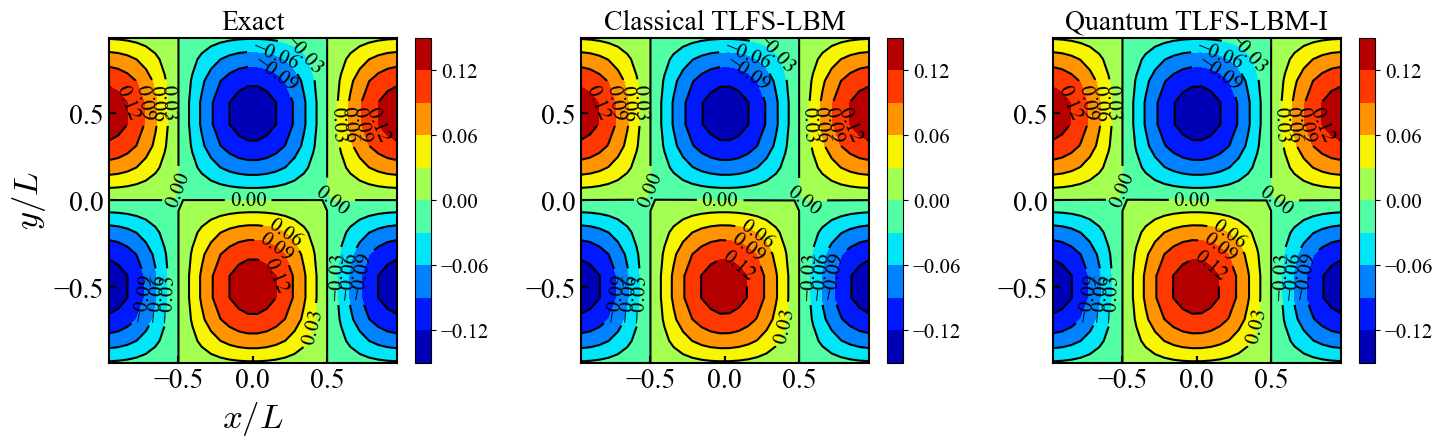

In [ ]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
ax01=plt.contourf(X/Lx,Y/Lx,u_exact/U, 9,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X/Lx,Y/Lx,u_exact/U,9,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)

ax1.set_xlabel('$x/L$', size = 25,fontdict = font1)
ax1.set_ylabel('$y/L$', size = 25,fontdict = font1)    
ax1.set_title('Exact', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
ax02=plt.contourf(X/Lx,Y/Lx,u[:,:,0]/U, 9,cmap='jet')
ax002 = plt.colorbar(ax02)
ax002.ax.tick_params(labelsize=15)
CS1=plt.contour(X/Lx,Y/Lx,u[:,:,0]/U,9,colors='k',linestyles='-',zorder=10)
ax2.clabel(CS1, inline=True, fontsize=15)
ax2.set_title('Classical TLFS-LBM', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)


ax3 = plt.axes([0.528, 0.2, 0.18, 0.65])

ax03=plt.contourf(X/Lx,Y/Lx,Psi_qlbm1[t+1,:,:]/U, 9,cmap='jet')
ax003 = plt.colorbar(ax03)
ax003.ax.tick_params(labelsize=15)
CS2=plt.contour(X/Lx,Y/Lx,Psi_qlbm1[t+1,:,:]/U,9,colors='k',linestyles='-',zorder=10)
ax3.clabel(CS2, fontsize=15,colors='k')
ax3.set_title('Quantum TLFS-LBM-I', fontsize = 20,fontdict = font)
ax3.tick_params(labelsize=20)

ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax3.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)

#plt.savefig('Re_10_u—1.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()



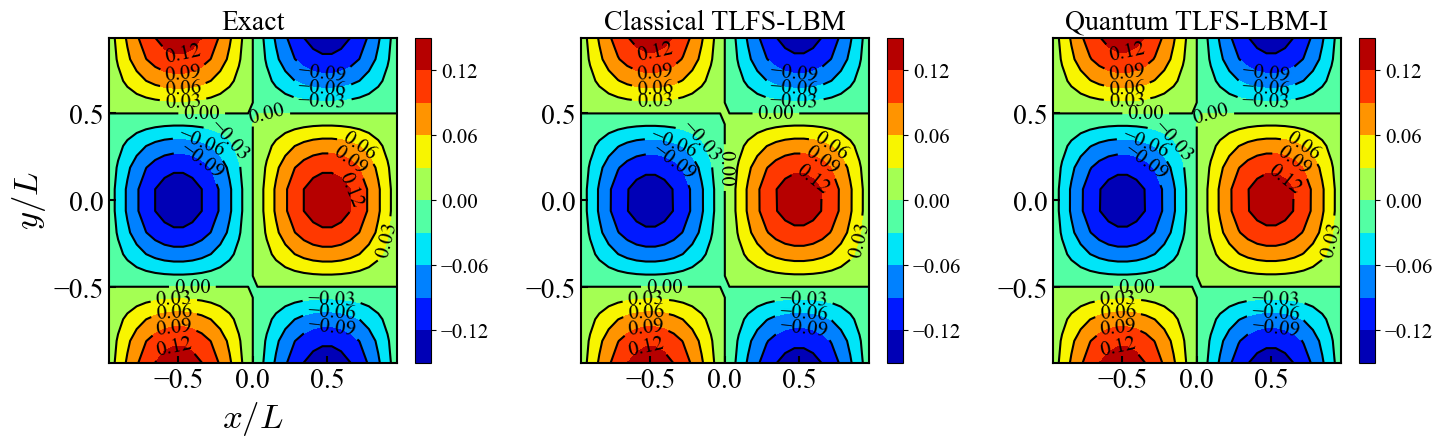

In [ ]:
import matplotlib
font = {'family': 'Times New Roman',}
font1 = {'family': 'Times New Roman','style': 'italic',}
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'

fig = plt.figure(figsize=(20, 5))
ax1 = plt.axes([0.056, 0.2, 0.18, 0.65])
ax01=plt.contourf(X/Lx,Y/Lx,v_exact/U, 9,cmap='jet')
ax001 = plt.colorbar(ax01)
ax001.ax.tick_params(labelsize=15)
CS=plt.contour(X/Lx,Y/Lx,v_exact/U,9,colors='k',linestyles='-',zorder=10)
ax1.clabel(CS, inline=True, fontsize=15)
ax1.set_xlabel('$x/L$', size = 25,fontdict = font1)
ax1.set_ylabel('$y/L$', size = 25,fontdict = font1)    
ax1.set_title('Exact', fontsize = 20,fontdict = font)
ax1.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax1.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)

ax2 = plt.axes([0.292, 0.2, 0.18, 0.65])
ax02=plt.contourf(X/Lx,Y/Lx,u[:,:,1]/U, 8,cmap='jet')
ax002 = plt.colorbar(ax02)
ax002.ax.tick_params(labelsize=15)
CS1=plt.contour(X/Lx,Y/Lx,u[:,:,1]/U,8,colors='k',linestyles='-',zorder=10)
ax2.clabel(CS1, inline=True, fontsize=15)
ax2.set_title('Classical TLFS-LBM', fontsize = 20,fontdict = font)
ax2.tick_params(labelsize=20)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax2.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)


ax3 = plt.axes([0.528, 0.2, 0.18, 0.65])
ax03=plt.contourf(X/Lx,Y/Lx,Psi_qlbm2[t+1,:,:]/U, 8,cmap='jet')
ax003 = plt.colorbar(ax03)
ax003.ax.tick_params(labelsize=15)
CS2=plt.contour(X/Lx,Y/Lx,Psi_qlbm2[t+1,:,:]/U,8,colors='k',linestyles='-',zorder=10)
ax3.clabel(CS2, fontsize=15,colors='k')
ax3.set_title('Quantum TLFS-LBM-I', fontsize = 20,fontdict = font)
ax3.tick_params(labelsize=20)

ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax3.tick_params(axis="both", which="major", direction="in", width=1.5, length=5)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)

#plt.savefig('Re_10_v—1.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

